In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)

2.19.0


In [9]:
observations =  10000
xs=np.random.uniform(low=-10,high=10,size=(observations,1))
zs=np.random.uniform(low=-10,high=10,size=(observations,1))
inputs = np.column_stack((xs,zs))
print(inputs.shape)

(10000, 2)


In [3]:
noise = np.random.uniform(low = -1,high=1,size=(observations,1))
targets = 2*xs - 3 * zs + 5 + noise
np.savez('TF_dataset', inputs = inputs, targets = targets)
print(targets.shape)

(1000, 1)


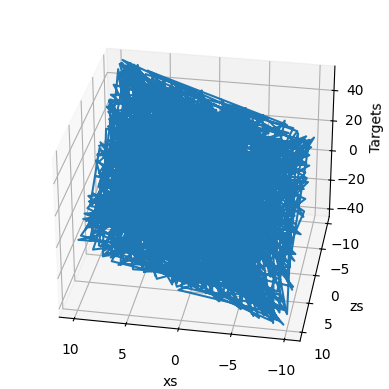

In [4]:
targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs, zs, targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [5]:
init_range = 0.1
weights = np.random.uniform(low=-init_range, high=init_range, size=(2,1))
biases = np.random.uniform(low=-init_range, high=init_range, size=1)
print(weights, biases)

[[-0.05697681]
 [-0.06020646]] [-0.00075189]


In [6]:
targets = targets.reshape(observations,1) #!!!!!!!!!! przeksztalcic z powrotem
eta = 0.01
for i in range (100):
    outputs = np.dot(inputs, weights) + biases
    deltas = outputs - targets

    loss = np.sum(deltas ** 2)/2/observations
    print(loss)

    deltas_scaled = deltas/observations
    weights = weights - eta * np.dot(inputs.T, deltas_scaled)
    biases = biases - eta * np.sum(deltas_scaled)

248.17710817483487
109.08727632894438
51.8262258055065
28.172522524589894
18.323344256611964
14.146183870942343
12.301127563351724
11.41645417944754
10.928746294673974
10.606551829903223
10.354758937361474
10.134253687600136
9.928922974466474
9.732102000358418
9.54100782531167
9.35445296042088
9.1719061872922
8.993106748316201
8.817905841696934
8.646201489009801
8.477911760298793
8.312963757422317
8.15128907180021
7.992821902547327
7.837498268025202
7.685255666991444
7.536032924800667
7.389770115944451
7.2464085182494635
7.105890580365256
6.968159894986583
6.833161174699357
6.700840229165979
6.571143943117068
6.444020254925181
6.319418135663418
6.197287568604011
6.0775795291337085
5.9602459650717154
5.845239777379756
5.732514801255469
5.622025787601113
5.513728384859978
5.40757912121312
5.303535387129263
5.201555418260841
5.101598278679302
5.003623844442962
4.907592787490792
4.813466559855679
4.721207378190835
4.630778208603135
4.5421427517872655
4.455265428454795
4.37011136505222
4.28

In [7]:
print(weights, biases)

[[ 2.01724727]
 [-3.00118065]] [3.18383676]


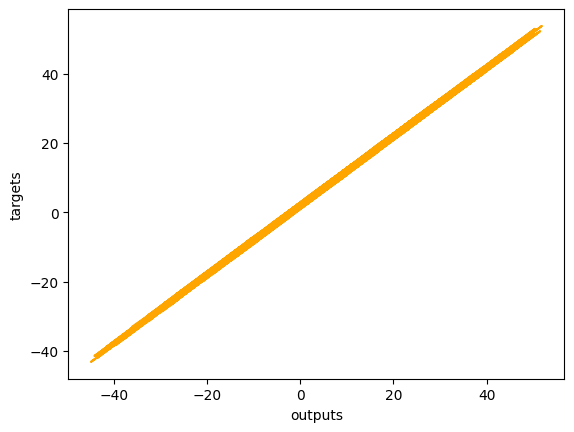

In [8]:
plt.plot(outputs, targets, color='orange')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()